## Libaries


In [1]:
# libs needed
# !pip install torch numpy matplotlib torchview torchvision scikit-learn
import tarfile
import pickle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

print("ok :)")

ok :)


# Load CIFAR-10 Dataset

In [2]:
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision import transforms, datasets


###########################################################################
# Transform the train and validation dataset
# CIFAR-10 mean and std, since your images are already scaled to [0, 1]
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

# Training transform: data augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Validation/test transform: no random augmentation
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


###########################################################################
#Load datasets train dataset
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=None)

#Split the full traning dataset into train and validation
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split( 
    full_train_dataset, [train_size, val_size] )

# Do the transform
train_dataset.dataset.transform = transform_train  # affects only Subset view
val_dataset.dataset.transform = transform_train

# Batch size
batch_size = 64

# Create loaders for train and validation dataset
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True)

val_loader = DataLoader( 
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False )


###########################################################################
# Test dataset
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)


###########################################################################
# Check it works
classes = test_loader.dataset.classes
print(classes)

/home/akselu24/Documents/AI_Tools_F26/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


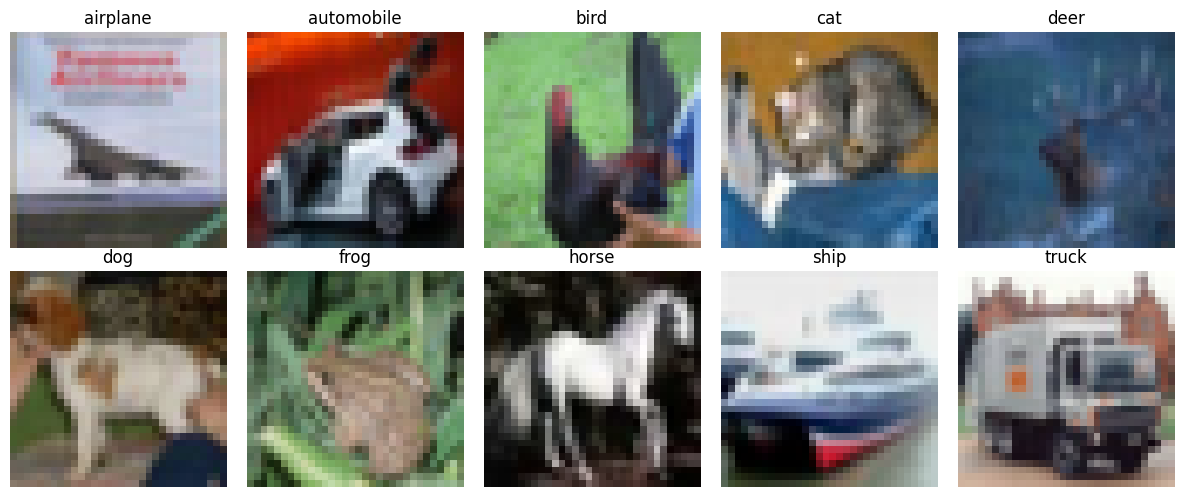

In [3]:
import matplotlib.pyplot as plt
import torch

# CIFAR-10 class names
classes = test_dataset.classes

# Mean and std used in Normalize
mean_tensor = torch.tensor(mean).view(3, 1, 1)
std_tensor = torch.tensor(std).view(3, 1, 1)

def unnormalize(image):
    image = image * std_tensor + mean_tensor
    image = torch.clamp(image, 0, 1)
    return image


# Find one image from each class
images_per_class = {}
labels_per_class = {}

for image, label in test_dataset:
    if label not in images_per_class:
        images_per_class[label] = image
        labels_per_class[label] = label

    if len(images_per_class) == 10:
        break


# Plot one image from each class
plt.figure(figsize=(12, 5))

for i in range(10):
    image = images_per_class[i]
    image = unnormalize(image)

    # Convert from PyTorch format: [C, H, W] to matplotlib format: [H, W, C]
    image = image.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(classes[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Setting up MobileNetV1

In [4]:
import torch
# all nn libraries nn.layer, convs and loss functions

import torch.nn as nn
# Display Image

from IPython.display import Image

# visualisation
# !pip install torchview
import torchvision
from torchview import draw_graph



########################################################3


class DepthWiseSeperable(nn.Module):

    def __init__(self, in_channels , out_channels , stride ):
        """
        DepthWiseSeperable block of MobileNet which performs the following operations:
        (a) depthwise convolution by applying a separate filter for each channel
        (b) pointwise convolutions are applied which combine the filtered result by implementing 1 × 1 convolution
        
            Note:
                1. groups = in_channels used for depthwise convolution
                2. in_channels and out_channels are same for depthwise convolution
                3. bias = False due to the usage of BatchNorm 
                4. To generate same height and width of output feature map as the input feature map, following should be padding for
                    * 1x1 conv : p=0
                    * 3x3 conv : p=1
                    * 5x5 conv : p=2


        Args:
          in_channels (int) : number of input channels
          out_channels (int) : number of output channels 
          stride (int) : stride used for depthwise convolution

        Attributes:
            Depthwise seperable convolutional block

        """

        super(DepthWiseSeperable,self).__init__()
        
        # groups used here
        self.depthwise = nn.Conv2d(in_channels = in_channels , out_channels = in_channels , stride = stride , padding = 1, kernel_size = 3 , groups=in_channels , bias = False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels = in_channels , out_channels = out_channels , stride = 1 , padding = 0, kernel_size = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        
        return x



################################################################################################33


class MobileNetV1(nn.Module):
    
    def __init__(self, num_classes=10):
        
        super(MobileNetV1, self).__init__()

        # Initial convolution layer
        self.features1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias = False),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
        )
        
        # Depthwise separable convolutions
        self.features = nn.Sequential(
            self.features1,                      # Inserting the above features here
            DepthWiseSeperable(32, 64, 1),
            DepthWiseSeperable(64, 128, 2),
            DepthWiseSeperable(128, 128, 1),
            DepthWiseSeperable(128, 256, 2),
            DepthWiseSeperable(256, 256, 1),
            DepthWiseSeperable(256, 512, 2),
            
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),

            DepthWiseSeperable(512, 1024, 2),
            DepthWiseSeperable(1024, 1024, 1)

        )
        
        # Average pooling and classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Training the model

In [ ]:
import torch.optim as optim
import torch.nn as nn
import copy

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


# Instantiate the model
model = MobileNetV1(num_classes=10).to(device)


# Define loss function and optimizer
lossFunction = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.001)


# Number of steps for training
num_epochs = 20

# Early stopping settings
patience = 10
best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_weights = copy.deepcopy(model.state_dict())


# For storing results
train_losses = []
train_accuracies = []
val_losses = [] 
val_accuracies = []


def evaluate(model, dataloader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, Y_batch in dataloader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)
            loss = lossFunction(outputs, Y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == Y_batch).sum().item()
            total += Y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total * 100

    return average_loss, accuracy


# Training loop
for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = lossFunction(outputs, Y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Save statistics
        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == Y_batch).sum().item()
        total += Y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total * 100

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    #Evaluate at epoch level
    val_loss, val_acc = evaluate(model, val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    


    print(
        f"Epoch [{epoch+1}/{num_epochs}]:  "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.2f}  |  %"
        f"Test Loss: {val_loss:.4f}, " 
        f"Test Acc: {val_acc:.2f}%"
    )


    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        # print("Validation loss improved. Saving model.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break




# Restore best model weights
model.load_state_dict(best_model_weights)


print('Training finished.')

# Evaluate !!!
print('\n')
test_loss, test_acc = evaluate(model, test_loader)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.2f}%")

cpu
Epoch [1/100] Train Loss: 1.9798, Train Acc: 26.45  |  %Test Loss: 1.7586, Test Acc: 34.67%
Epoch [2/100] Train Loss: 1.6751, Train Acc: 37.80  |  %Test Loss: 1.6107, Test Acc: 42.10%
Epoch [3/100] Train Loss: 1.5440, Train Acc: 43.17  |  %Test Loss: 1.4976, Test Acc: 44.90%
Epoch [4/100] Train Loss: 1.4493, Train Acc: 46.95  |  %Test Loss: 1.4425, Test Acc: 47.77%
Epoch [5/100] Train Loss: 1.3673, Train Acc: 50.59  |  %Test Loss: 1.3911, Test Acc: 50.94%
Epoch [6/100] Train Loss: 1.3006, Train Acc: 53.39  |  %Test Loss: 1.2536, Test Acc: 55.38%
Epoch [7/100] Train Loss: 1.2287, Train Acc: 56.27  |  %Test Loss: 1.1447, Test Acc: 59.19%
Epoch [8/100] Train Loss: 1.1537, Train Acc: 58.89  |  %Test Loss: 1.0864, Test Acc: 60.64%
Epoch [9/100] Train Loss: 1.0964, Train Acc: 61.36  |  %Test Loss: 1.0562, Test Acc: 63.36%
Epoch [10/100] Train Loss: 1.0353, Train Acc: 63.44  |  %Test Loss: 0.9920, Test Acc: 65.18%
Epoch [11/100] Train Loss: 0.9962, Train Acc: 64.94  |  %Test Loss: 0.9437,

KeyboardInterrupt: 

# Plot...

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy during training")
plt.legend()
plt.grid()
plt.show()

# Evaluate the model

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

model.eval()

def get_predictions_from_loader(model, dataloader):
    all_preds = []
    all_true = []

    with torch.no_grad():
        for X_batch, Y_batch in dataloader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_true.append(Y_batch.cpu())

    y_pred = torch.cat(all_preds)
    y_true = torch.cat(all_true)

    return y_true, y_pred

In [ ]:
# Get predictions
y_true_train, y_pred_train = get_predictions_from_loader(model, train_loader)
y_true_val, y_pred_val = get_predictions_from_loader(model, val_loader)
y_true_test, y_pred_test = get_predictions_from_loader(model, test_loader)

# Accuracy
train_acc = (y_pred_train == y_true_train).float().mean().item() * 100
val_acc = (y_pred_val == y_true_val).float().mean().item() * 100
test_acc = (y_pred_test == y_true_test).float().mean().item() * 100

print(f"Accuracy on training data: {train_acc:.2f}%")
print(f"Accuracy on validation data: {val_acc:.2f}%")
print(f"Accuracy on test data: {test_acc:.2f}%")

In [ ]:
# Classification report
print("\nClassification report on test data:")
print(classification_report(y_true_test.numpy(), y_pred_test.numpy(), target_names=classes))

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import torch

# Get true labels and predicted probabilities
test_labels = []
y_score = []

model.eval()
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        probabilities = torch.softmax(outputs, dim=1)

        test_labels.extend(Y_batch.numpy())
        y_score.extend(probabilities.cpu().numpy())

# Binarize labels
n_classes = len(classes)
y_true = label_binarize(test_labels, classes=list(range(n_classes)))
y_score = np.array(y_score)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve - One vs Rest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

## Visualize the confusion matrix


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true_test.numpy(), y_pred_test.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix - Test Data")
plt.show()